In [85]:
from braincoder.models import RegressionGaussianPRF
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

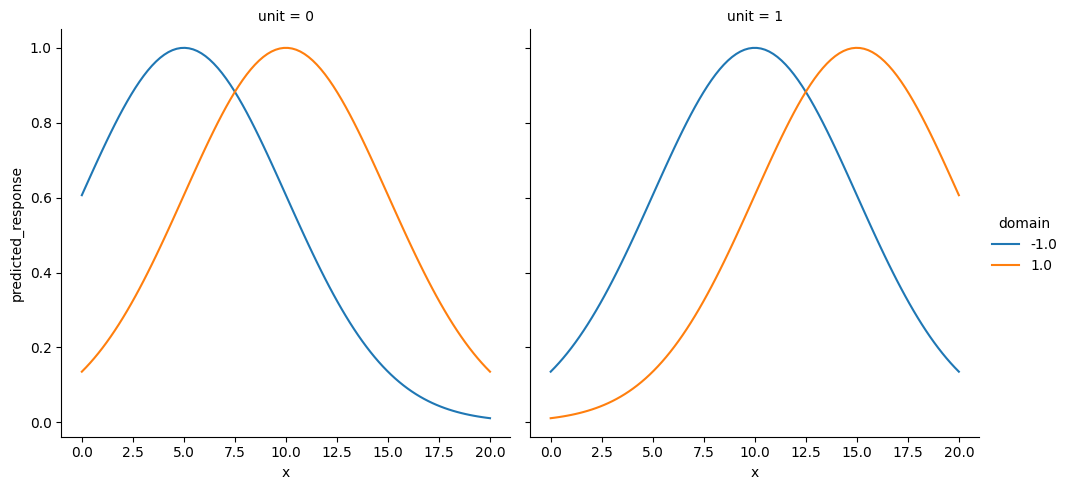

In [37]:
parameters = pd.DataFrame({'sd_unbounded':[5, 5,], 'amplitude_unbounded':[1., 1.], 'baseline_unbounded':[0., 0.]})

# Make columns a MultiIndex, where the 2nd level is always 'Intercept'
parameters.columns = pd.MultiIndex.from_product([parameters.columns, ['Intercept']])

parameters[('mu_unbounded', 'C(domain)[-1.0]')] = np.array([5, 10])
parameters[('mu_unbounded', 'C(domain)[1.0]')] = np.array([10, 15])

# parameters[('mu', 'C(domain).T')]


paradigm = pd.DataFrame({'x':np.tile(np.linspace(0, 20, 100), 2), 'domain':np.repeat([-1, 1], 100)}).astype(np.float32)

paradigm


model = RegressionGaussianPRF(paradigm=paradigm, regressors={'mu':'0 + C(domain)'},parameters=parameters)

pred = model.predict(paradigm=paradigm, parameters=parameters)
pred.columns.name = 'unit'

pred = pred.set_index(pd.MultiIndex.from_frame(paradigm)).stack().to_frame('predicted_response')

sns.relplot(data=pred.reset_index(), x='x', y='predicted_response', hue='domain', kind='line', palette='tab10', col='unit')

In [108]:
omega = np.identity(2, dtype=np.float32) * .1

In [109]:
from scipy import stats as ss
random_data = pd.DataFrame(ss.multivariate_normal.rvs(mean=[0, 0], cov=omega, size=2))

stimulus_range = paradigm

model.get_stimulus_pdf(random_data, stimulus_range, omega=omega)



x,0.000000,0.202020,0.404040,0.606061,0.808081,1.010101,1.212121,1.414141,1.616162,1.818182,...,18.181818,18.383839,18.585859,18.787878,18.989899,19.191919,19.393940,19.595959,19.797979,20.000000
domain,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
0,0.003568,0.002525,0.001771,0.001233,0.000852,0.000586,0.000401,0.000273,0.000186,0.000127,...,0.001446,0.002086,0.002987,0.004244,0.005977,0.008337,0.011508,0.015713,0.021208,0.028283
1,0.194599,0.165553,0.139647,0.116828,0.096973,0.079898,0.065378,0.053162,0.042988,0.034592,...,0.013757,0.017221,0.021505,0.026764,0.033169,0.040904,0.050159,0.061124,0.073980,0.088893


In [110]:
simulated_data = model.simulate(paradigm=paradigm, parameters=parameters, noise=omega, n_repeats=100)

simulated_data 

(100, 200, 2)


unit                    0         1
repeat stimulus                    
0      0         0.551938 -0.324556
       1         1.128131  0.236527
       2         0.342707  0.360336
       3         0.731069  0.773650
       4         0.725556  0.748078
...                   ...       ...
99     195       0.672981  0.849495
       196       0.261164  0.242447
       197      -0.105694  0.748904
       198      -1.030750  0.955576
       199       0.482333  0.577028

[20000 rows x 2 columns]

In [111]:
simulated_data = model.simulate(paradigm=paradigm, parameters=parameters, noise=omega, n_repeats=100)

simulated_data = simulated_data.unstack('repeat')

simulated_data.index = pd.MultiIndex.from_frame(paradigm)

simulated_data = simulated_data.stack()

(100, 200, 2)


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_11243/3601126039.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  simulated_data = simulated_data.stack()


In [112]:
pdf = model.get_stimulus_pdf(simulated_data, stimulus_range, omega=omega)


In [113]:
def get_mean_posterior(pdf):

    pdf = pdf / np.trapz(pdf, pdf.columns, axis=1)[:, np.newaxis]

    E = np.trapz(pdf * pdf.columns.values[np.newaxis, :], pdf.columns, axis=1)

    return E

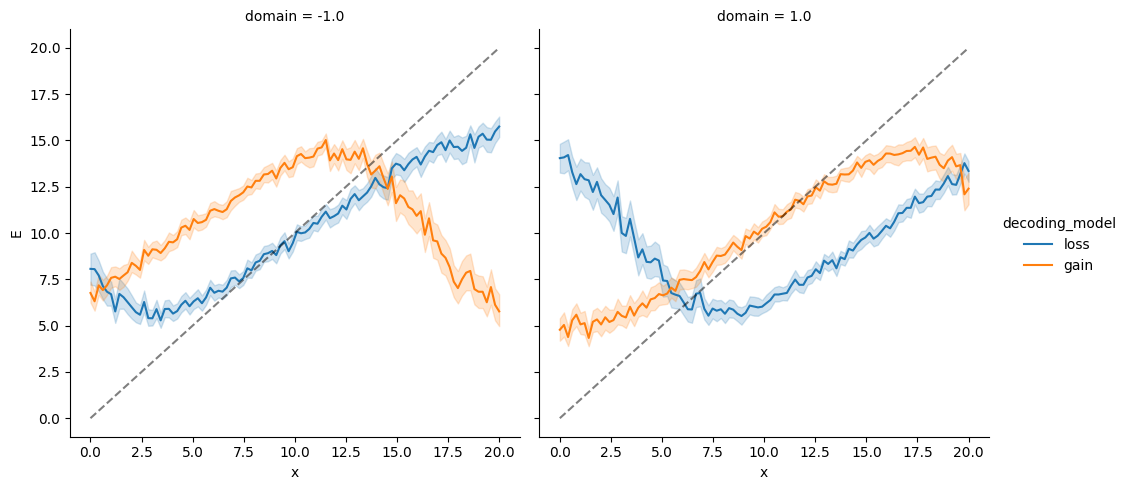

In [115]:
E1 = pd.DataFrame(get_mean_posterior(pdf.xs(-1, level='domain', axis=1)), columns=['E'])

E1['decoding_model'] = 'loss'
E1['x'] = pdf.index.get_level_values('x')
E1['domain'] = pdf.index.get_level_values('domain')

E2 = pd.DataFrame(get_mean_posterior(pdf.xs(1, level='domain', axis=1)), columns=['E'])
E2['decoding_model'] = 'gain'
E2['x'] = pdf.index.get_level_values('x')
E2['domain'] = pdf.index.get_level_values('domain')


E = pd.concat([E1, E2])

g = sns.relplot(data=E, x='x', y='E', col='domain', kind='line', palette='tab10', hue='decoding_model')

for ax in g.axes.flat:
    ax.plot(paradigm['x'], paradigm['x'], 'k--', alpha=.5)







In [105]:
g

In [ ]:
pdf.groupby('domain', axis=1).apply(lambda d: np.trapz(d * d.columns[np.newaxis, :])

x                  0.000000  0.202020  0.404040  0.606061  0.808081   \
domain                  -1.0      -1.0      -1.0      -1.0      -1.0   
x    domain repeat                                                     
0.0  -1.0   0       0.294793  0.321354  0.349662  0.379666  0.411285   
            1       0.994894  0.987520  0.976873  0.962995  0.945992   
            2       0.652532  0.688464  0.724269  0.759559  0.793922   
            3       0.993069  0.998541  1.000000  0.997274  0.990272   
            4       0.976956  0.965892  0.952768  0.937701  0.920839   
...                      ...       ...       ...       ...       ...   
20.0  1.0   95      0.014842  0.014631  0.014445  0.014286  0.014158   
            96      0.921520  0.895102  0.865206  0.832143  0.796299   
            97      0.025898  0.027787  0.029846  0.032093  0.034547   
            98      0.042049  0.039269  0.036677  0.034273  0.032057   
            99      0.122980  0.136255  0.150841  0.166817  0.184256   

x                  1.010101  1.212121  1.414141  1.616162  1.818182   ...  \
domain                  -1.0      -1.0      -1.0      -1.0      -1.0  ...   
x    domain repeat                                                    ...   
0.0  -1.0   0       0.444403  0.478867  0.514491  0.551050  0.588289  ...   
            1       0.926026  0.903313  0.878115  0.850733  0.821495  ...   
            2       0.826931  0.858157  0.887176  0.913584  0.937006  ...   
            3       0.978984  0.963491  0.943956  0.920625  0.893814  ...   
            4       0.902362  0.882470  0.861386  0.839341  0.816573  ...   
...                      ...       ...       ...       ...       ...  ...   
20.0  1.0   95      0.014066  0.014015  0.014008  0.014051  0.014151  ...   
            96      0.758114  0.718075  0.676693  0.634493  0.591989  ...   
            97      0.037233  0.040177  0.043408  0.046963  0.050879  ...   
            98      0.030024  0.028172  0.026495  0.024987  0.023643  ...   
            99      0.203225  0.223782  0.245974  0.269835  0.295384  ...   

x                  18.181818 18.383839 18.585859 18.787878 18.989899  \
domain                   1.0       1.0       1.0       1.0       1.0   
x    domain repeat                                                     
0.0  -1.0   0       0.137598  0.130386  0.123611  0.117236  0.111228   
            1       0.195003  0.204266  0.214056  0.224336  0.235058   
            2       0.123647  0.122513  0.121535  0.120683  0.119926   
            3       0.081278  0.085327  0.089725  0.094469  0.099550   
            4       0.732305  0.753375  0.774049  0.794114  0.813359   
...                      ...       ...       ...       ...       ...   
20.0  1.0   95      0.912234  0.876308  0.836117  0.792606  0.746723   
            96      0.039637  0.043406  0.047630  0.052342  0.057579   
            97      0.435989  0.395614  0.357497  0.321809  0.288652   
            98      0.932720  0.957360  0.976604  0.990183  0.997966   
            99      0.164866  0.151306  0.138775  0.127211  0.116554   

x                  19.191919 19.393940 19.595959 19.797979 20.000000  
domain                   1.0       1.0       1.0       1.0       1.0  
x    domain repeat                                                    
0.0  -1.0   0       0.105556  0.100196  0.095125  0.090325  0.085780  
            1       0.246168  0.257604  0.269297  0.281173  0.293154  
            2       0.119240  0.118599  0.117983  0.117372  0.116750  
            3       0.104957  0.110676  0.116686  0.122966  0.129486  
            4       0.831578  0.848576  0.864178  0.878229  0.890599  
...                      ...       ...       ...       ...       ...  
20.0  1.0   95      0.699392  0.651474  0.603749  0.556898  0.511492  
            96      0.063372  0.069750  0.076742  0.084366  0.092640  
            97      0.258069  0.230052  0.204547  0.181462  0.160682  
            98      0.999962  0.996316  0.987296  0

<Axes: xlabel='x-domain', ylabel='x-domain'>

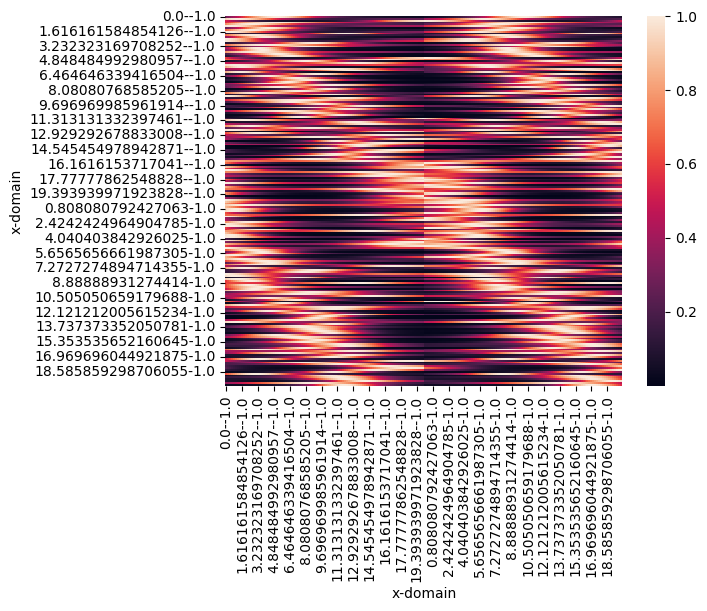

In [65]:
sns.heatmap(pdf.xs(0, level='repeat'))

In [57]:
simulated_data

unit                     0                                                    \
repeat                  0         1         2         3         4         5    
x         domain                                                               
0.000000  -1.0    0.459040  0.832341  0.510535  0.279252  0.266611  0.136499   
0.202020  -1.0    0.300526  0.622807  0.464472  0.866324  0.589844  0.826232   
0.404040  -1.0    0.820739  0.496547  0.713048  0.173674  0.997517  1.138675   
0.606061  -1.0    0.866090  1.239010  0.958102  1.133121  0.681480  1.380792   
0.808081  -1.0    1.147295  1.304344  1.013884  0.599407  1.021375  1.684384   
...                    ...       ...       ...       ...       ...       ...   
19.191919  1.0   -0.024065  0.764427  0.203268 -0.332622 -0.093104 -0.016642   
19.393940  1.0    0.495918  0.394773  0.301042 -0.011358  0.152157 -0.179947   
19.595959  1.0   -0.040816  0.121504 -0.120097  0.161445  0.103440  0.689001   
19.797979  1.0    0.624416  0.328868 -0.080545  0.183008 -0.035659 -0.209211   
20.000000  1.0   -0.786468  0.312854  0.454790  0.134584 -0.165257 -0.254227   

unit                                                      ...         1  \
repeat                  6         7         8         9   ...        90   
x         domain                                          ...             
0.000000  -1.0    0.834605  0.239350  1.425389  0.677136  ... -0.763330   
0.202020  -1.0    0.532211  0.565630  0.772224  1.151644  ...  0.323458   
0.404040  -1.0    1.213749  0.799640  0.411605  0.705803  ... -0.601490   
0.606061  -1.0    0.052108 -0.061555  1.010441  0.380678  ... -0.700496   
0.808081  -1.0    1.046845  0.347969  0.704312  0.073140  ... -0.003330   
...                    ...       ...       ...       ...  ...       ...   
19.191919  1.0    0.202561  0.166110 -0.521363  0.960162  ...  1.205090   
19.393940  1.0    0.739622  0.348750  0.057967  0.007259  ... -0.312440   
19.595959  1.0    0.060676  0.113799  0.567592 -0.414153  ...  1.516598   
19.797979  1.0    0.061090 -0.614533  0.049768 -0.597164  ...  0.379777   
20.000000  1.0    0.092055  0.373839  0.363441 -0.290289  ...  0.724656   

unit                                                                          \
repeat                  91        92        93        94        95        96   
x         domain                                                               
0.000000  -1.0    0.650237  0.349235 -0.155544  0.507251 -0.443294  0.547208   
0.202020  -1.0    0.244491 -0.221960  0.646590  0.417627  0.054153  0.867457   
0.404040  -1.0    0.102481  0.106399 -0.053452  1.033239 -0.083245  0.438703   
0.606061  -1.0   -0.001826 -0.790398  0.443920  0.464880 -1.078774 -0.124082   
0.808081  -1.0    0.089857  0.578008  0.939028  0.801856  0.503144 -0.062801   
...                    ...       ...       ...       ...       ...       ...   
19.191919  1.0    1.330732 -0.424318  1.439394  0.792860  1.135846  0.565895   
19.393940  1.0    0.831758  1.187673  0.699474  2.219081  1.024080  0.994141   
19.595959  1.0    1.279391  1.013229  0.723071  0.530071 -0.068127  0.879620   
19.797979  1.0    0.608583  0.890738  0.933052  1.387632  1.272823  1.071619   
20.000000  1.0    0.734283  1.288394  0.755876  0.491301  0.418011  0.566725   

unit                                            
repeat                  97        98        99  
x         domain                                
0.000000  -1.0    0.059844 -0.859451 -0.410106  
0.202020  -1.0    0.873948 -0.332119  0.826709  
0.404040  -1.0    0.008079  0.531570 -0.192872  
0.606061  -1.0   -0.329449 -0.114980 -0.342869  
0.808081  -1.0   -0.263357  0.595940  0.562095  
...                    ...       ...       ...  
19.191919  1.0    0.593707  1.032894 -0.202277  
19.393940  1.0    0.081023  2.046899  0.655844  
19.595959  1.0    0.019980  0.824495 -0.008176  
19.797979  1.0    0.949427  0.241751  0.538475  
20.000000  1.0    1.002734  0.932538  1.388002  

[200 rows x 200 colu

In [22]:
parameters

sd_unbounded amplitude_unbounded baseline_unbounded  mu_unbounded  \
     Intercept           Intercept          Intercept C(domain)[-1]   
0            5                 1.0                0.0             5   
1            5                 1.0                0.0            10   

                
  C(domain)[1]  
0           10  
1           15